# Wykresy danych z pliku data.csv
Poniżej odczytuję `data.csv` oraz rysuję wykresy temperatur i ciśnień dla wybranych kolumn.

In [7]:
import pandas as pd

df = pd.read_csv("data.csv")
df["newpressurefeedpressevent"] += 23.98677
df["newpressurefeedpressevent"] /= 41.66667

df["newpressurefeedpressevent"] *= 166.66667
df["newpressurefeedpressevent"] -= 99

df.to_csv("data.csv")

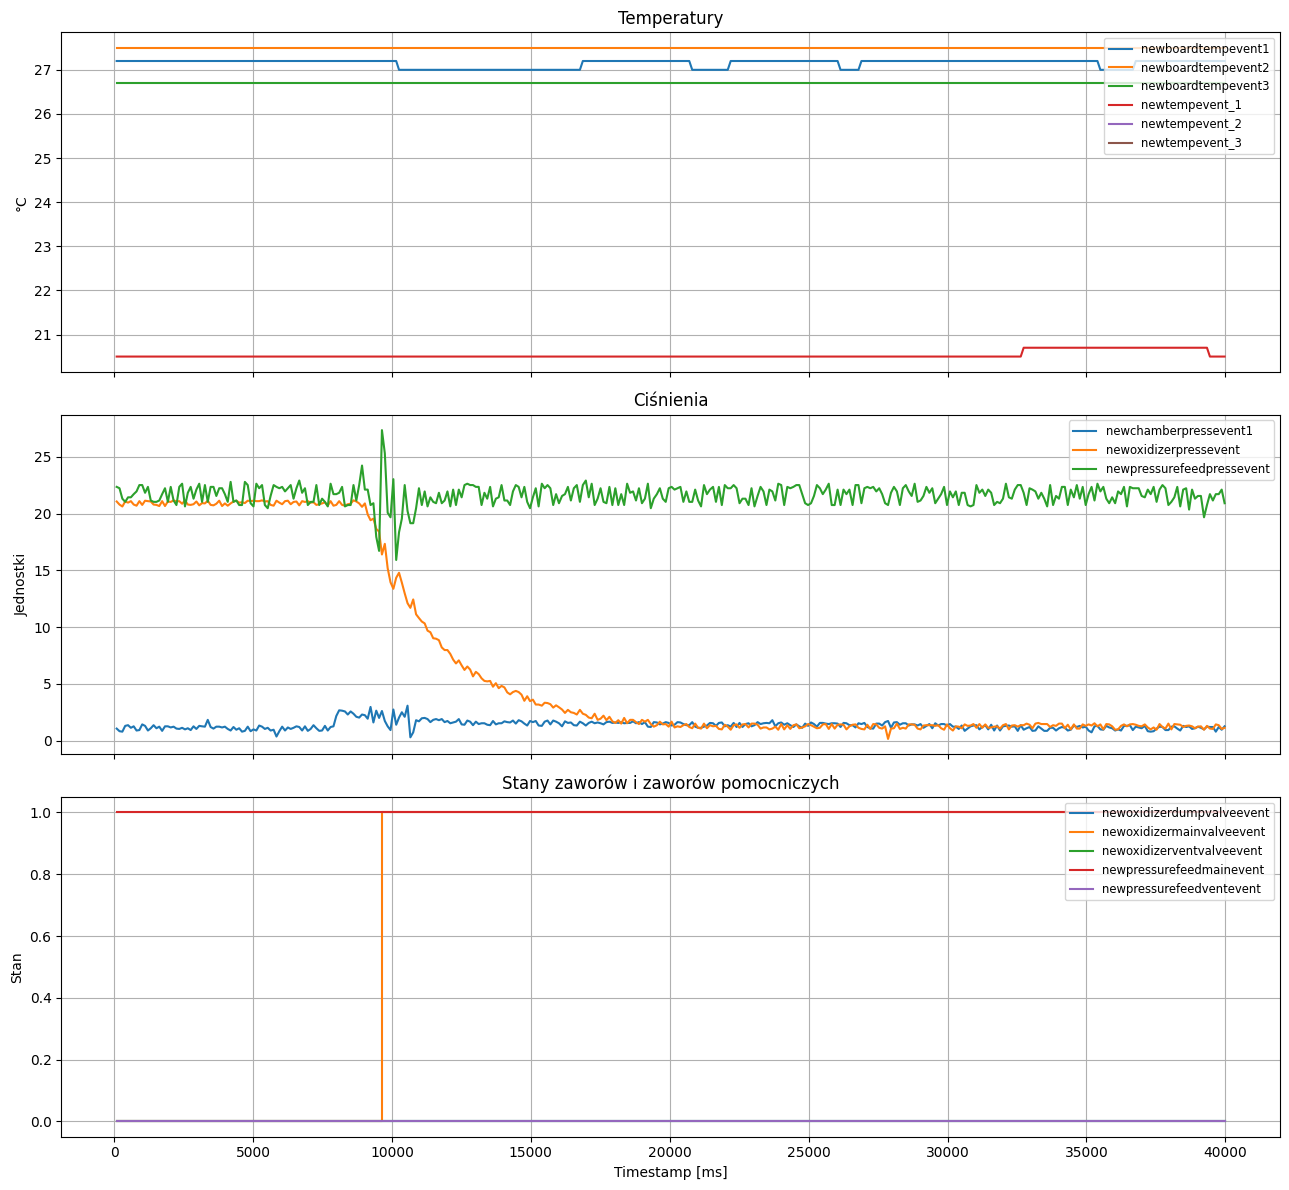

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

path = Path('data.csv')
df = pd.read_csv(path)

# konwersja znacznika czasu na datetime
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='%H:%M:%S.%f', errors='coerce')
    df['timestamp_ms'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds() * 1000

# wybór kolumn do rysowania
temperature_columns = [
    'newboardtempevent1',
    'newboardtempevent2',
    'newboardtempevent3',
    'newtempevent_1',
    'newtempevent_2',
    'newtempevent_3',
]
pressure_columns = [
    'newchamberpressevent1',
    'newoxidizerpressevent',
    'newpressurefeedpressevent',
]

# Konwersja wartości do liczb i usuwanie nieprawidłowych
for col in temperature_columns + pressure_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


state_columns = [
    'newoxidizerdumpvalveevent',
    'newoxidizermainvalveevent',
    'newoxidizerventvalveevent',
    'newpressurefeedmainevent',
    'newpressurefeedventevent',
]
for col in state_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Ograniczenie danych do zakresu czasowego i przesunięcie osi czasu
if 'timestamp_ms' in df.columns:
    time_min = 340000
    time_max = 380000
    df = df[(df['timestamp_ms'] >= time_min) & (df['timestamp_ms'] <= time_max)].copy()
    df['timestamp_ms'] = df['timestamp_ms'] - time_min

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

for col in temperature_columns:
    if col in df.columns:
        axes[0].plot(df['timestamp_ms'] if 'timestamp' in df.columns else df.index, df[col], label=col)
axes[0].set_title('Temperatury')
axes[0].set_ylabel('°C')
axes[0].legend(loc='upper right', fontsize='small')
axes[0].grid(True)

for col in pressure_columns:
    if col in df.columns:
        axes[1].plot(df['timestamp_ms'] if 'timestamp' in df.columns else df.index, df[col], label=col)
axes[1].set_title('Ciśnienia')
axes[1].set_ylabel('Jednostki')
axes[1].legend(loc='upper right', fontsize='small')
axes[1].grid(True)

for col in state_columns:
    if col in df.columns:
        axes[2].step(df['timestamp_ms'] if 'timestamp' in df.columns else df.index, df[col].fillna(0), where='post', label=col)
axes[2].set_title('Stany zaworów i zaworów pomocniczych')
axes[2].set_ylabel('Stan')
axes[2].set_xlabel('Timestamp [ms]')
axes[2].legend(loc='upper right', fontsize='small')
axes[2].grid(True)

plt.tight_layout()
plt.show()
